In [67]:
from stmorlet import Morlet2D1T
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
from matplotlib.animation import FuncAnimation
import os
from astropy.io import fits
import re
from datetime import datetime
import scipy.signal
from scipy.interpolate import griddata
from scipy.optimize import curve_fit
%matplotlib ipympl

In [76]:
comp_fits_dir = "../data/fits_20120327_morton/"
comp_fits_list = os.listdir(comp_fits_dir)
comp_fits_list.sort()
already_crop_data = False

for i, comp_fits in enumerate(comp_fits_list):
    from astropy.io import fits
    hdul = fits.open(comp_fits_dir+comp_fits)
    obstime = hdul[0].header['DATE-OBS']+' '+hdul[0].header['TIME-OBS']
    if i == 0:
        print(hdul[0].header['CDELT1'])
    doppler_map = hdul[3].data
    enhanced_intensity = hdul[1].data
    if not already_crop_data:
        sequence_doppler_map = np.copy(doppler_map[530:590, 250:370])
        already_crop_data = True
    else:
        sequence_doppler_map = np.dstack([sequence_doppler_map, doppler_map[530:590, 250:370]])

comp_data = np.transpose(sequence_doppler_map, (0,1,2))[:, :, 35:170]

4.46


In [77]:
data_padding = np.zeros((120, 180, 135))
data_padding[30:90, 30:150, :] = np.copy(comp_data)

In [75]:
morlet = Morlet2D1T(
    dx=3.234,
    dy=3.234,
    dt=30,
    epsilon=1.0,
    k0=2.0,
    omega0=4.0,
    precision="single",
    backend="gpu",
    device=None,
    boundary=None,
)

In [2]:
omega_array = 2*np.pi*np.linspace(2, 10, 25)*1e-3
k_array = np.linspace(0.05, 0.15, 25)
theta_array = np.linspace(-15, 15, 15)

In [ ]:
psd_out_path = morlet.psd_polar(data_padding, k_array, theta_array, omega_array, output='memmap', path='./data/comp_out_psd.npy',
                                overwrite=True, memory_fraction=0.3)
psd_in_path = morlet.psd_polar(data_padding, k_array, theta_array+180, omega_array, output='memmap', path='./data/comp_in_psd.npy',
                               overwrite=True, memory_fraction=0.3)

In [ ]:
psd_out = np.load('./data/comp_out_psd.npy', mmap_mode='r')
psd_out = np.trapezoid(psd_out[30:90, 30:150, ...], x=theta_array, axis=-2)
psd_in = np.load('./data/comp_in_psd.npy', mmap_mode='r')
psd_in = np.trapezoid(psd_in[30:90, 30:150, ...], x=theta_array, axis=-2)

In [ ]:
np.save('./data/psd_in_integrated_on_theta.npy', psd_in)
np.save('./data/psd_out_integrated_on_theta.npy', psd_out)

In [3]:
psd_in = np.load('./data/psd_in_integrated_on_theta.npy')
psd_out = np.load('./data/psd_out_integrated_on_theta.npy')

Text(0.5, 1.0, 'Inflow log10(PSD)')

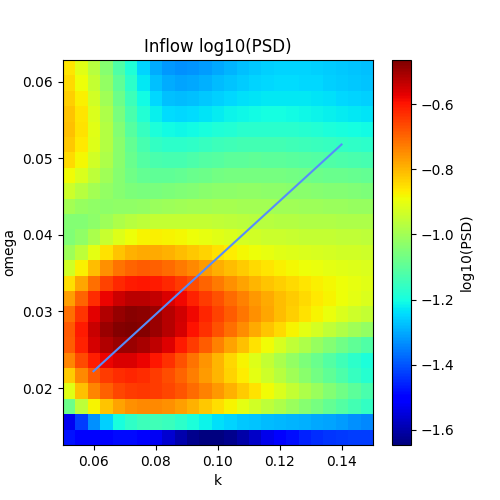

In [56]:
fig, ax = plt.subplots(figsize=(5, 5))
im1 = ax.imshow(np.log10(np.mean(psd_in[15:25, 55:65, 50:70, :, :], axis=(0, 1, 2))).T, origin='lower', cmap='jet',
          extent=(k_array.min(), k_array.max(), omega_array.min(), omega_array.max()))
ax.plot(np.array([0.06, 0.14]), np.array([0.06, 0.14])*0.37, label='370km/s')
plt.colorbar(im1, ax=ax, label='log10(PSD)')
ax.set_xlabel('k')
ax.set_ylabel('omega')
ax.set_aspect('auto')
ax.set_title('Inflow log10(PSD)')
ax.legend()

In [63]:
plt.close('all')

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(np.log10(np.mean(psd_out, axis=(2, 3, 4))), origin='lower', cmap='jet')
plt.colorbar(im, ax=ax, label='log10(PSD)')
ax.set_xlabel('y/pixel')
ax.set_ylabel( 'x/pixel')
ax.set_aspect('equal')
ax.set_title('Outflow log10(PSD) on x-y plane')

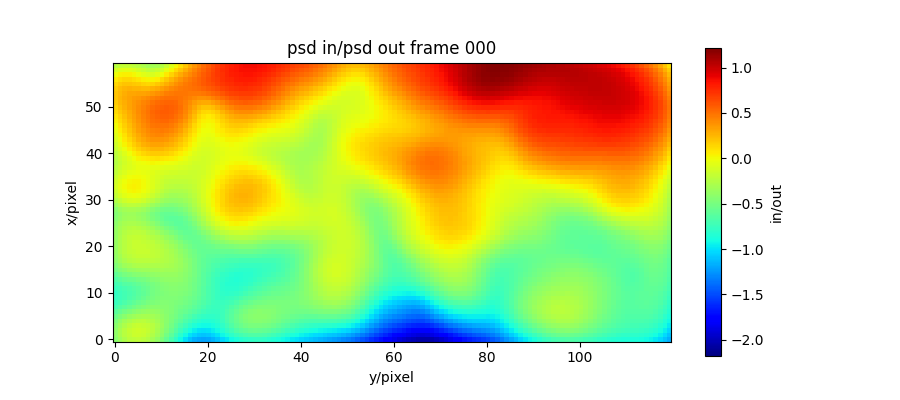

In [43]:
plot_data = np.log10(np.mean(psd_out, axis=(3, 4)))
# plot_data = np.mean(psd_in, axis=(3, 4)) / np.mean(psd_out, axis=(3, 4))
vmin = plot_data.min()
vmax = plot_data.max()
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(plot_data[:, :, 0], origin='lower', cmap='jet', vmin=vmin, vmax=vmax)
# plt.colorbar(im, ax=ax, label='log10(PSD)')
plt.colorbar(im, ax=ax, label='in/out')
ax.set_xlabel('y/pixel')
ax.set_ylabel( 'x/pixel')
ax.set_aspect('equal')
# ax.set_title('Outflow log10(PSD) on x-y plane')
title = ax.set_title('psd in/psd out frame 000')
def update(frame, im=im, title=title):
    im.set_data(plot_data[:, :, frame])
    title.set_text(f'psd in/psd out frame {frame:03d}')
    return im, title

ani = FuncAnimation(fig, update, frames=135, interval=20, blit=True)

In [33]:
plt.close('all')

### 内外传分块功率谱动画（5×5 像素）

使用已计算的 `psd_in/out(x,y,t,k,omega)`，无需重新运行小波变换。
选择原始像素 x[10:40]、y[20:100]，按 5×5 平均得到 6×16 个子图。
内传显示在负 k，外传显示在正 k，两个 imshow 之间保留未计算的空白区。
所有帧及两支共享色标；标题时间相对于输入第一帧。
本单元仅构建动画，不自动写出大量图片或视频。


In [ ]:
from pathlib import Path
import importlib.util

# 支持以工作总结目录或项目根目录作为 notebook 工作目录。
animation_module_path = Path('animate_directional_psd.py')
if not animation_module_path.is_file():
    animation_module_path = Path('工作总结/animate_directional_psd.py')
spec = importlib.util.spec_from_file_location('directional_psd_animation', animation_module_path)
animation_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(animation_module)

# 重运行单元时关闭旧窗口，并保留动画对象以避免被回收。
if 'fig_psd_blocks' in globals():
    plt.close(fig_psd_blocks)
fig_psd_blocks, ani_psd_blocks = animation_module.animate_directional_psd(
    psd_in, psd_out, k_array, omega_array, dt=30.0, interval=150,
)
plt.show()

# 可选：导出 GIF（启用后可能需要较长时间）。
ani_psd_blocks.save('./movie/psd_blocks_in_out.gif', writer='pillow', fps=5, dpi=80)


## 检查底部横向功率谱增强

In [73]:
omega_array_bottom = 2*np.pi*np.linspace(1, 4, 16)*1e-3
k_array_bottom = np.arange(0.01, 0.17, 0.01)

In [78]:
psd_out_bottom_band_path = morlet.psd_polar(data_padding, k_array_bottom, theta_array, omega_array_bottom, output='memmap', path='./data/comp_out_bottom_band_psd.npy',
                                overwrite=True, memory_fraction=0.3)
psd_in_bottom_band_path = morlet.psd_polar(data_padding, k_array_bottom, theta_array+180, omega_array_bottom, output='memmap', path='./data/comp_in_bottom_band_psd.npy',
                               overwrite=True, memory_fraction=0.3)

/tmp/ipykernel_2213487/570774116.py:1: RuntimeWarning: Morlet wavelet effective support exceeds the input extent along axes: x
  psd_out_bottom_band_path = morlet.psd_polar(data_padding, k_array_bottom, theta_array, omega_array_bottom, output='memmap', path='./data/comp_out_bottom_band_psd.npy',


PSD polar:   0%|          | 0/20 [00:00<?, ?block/s]

/tmp/ipykernel_2213487/570774116.py:3: RuntimeWarning: Morlet wavelet effective support exceeds the input extent along axes: x
  psd_in_bottom_band_path = morlet.psd_polar(data_padding, k_array_bottom, theta_array+180, omega_array_bottom, output='memmap', path='./data/comp_in_bottom_band_psd.npy',


PSD polar:   0%|          | 0/20 [00:00<?, ?block/s]

In [79]:
psd_out = np.load('./data/comp_out_bottom_band_psd.npy', mmap_mode='r')
psd_out = np.trapezoid(psd_out[30:90, 30:150, ...], x=theta_array, axis=-2)
psd_in = np.load('./data/comp_in_bottom_band_psd.npy', mmap_mode='r')
psd_in = np.trapezoid(psd_in[30:90, 30:150, ...], x=theta_array, axis=-2)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
im1 = ax.imshow(np.log10(np.mean(psd_in[15:25, 55:65, 50:70, :, :], axis=(0, 1, 2))).T, origin='lower', cmap='jet',
          extent=(k_array.min(), k_array.max(), omega_array.min(), omega_array.max()))
# ax.plot(np.array([0.06, 0.14]), np.array([0.06, 0.14])*0.37, label='370km/s')
plt.colorbar(im1, ax=ax, label='log10(PSD)')
ax.set_xlabel('k')
ax.set_ylabel('omega')
ax.set_aspect('auto')
# ax.set_title('Inflow log10(PSD)')
# ax.legend()